# Segmentación basada en color

Este proceso permite separar la imagen en regiones utilizando informacion del color.
En este ejercicio usted debe implementar la segmentacion de imagenes para los mod-
elos de color RGB y HSV. En cada caso debera determinar el subespacio a segmentar
para generar una mascara, que luego utilizara para extraer s ́olo la informaci ́on de
inter ́es de la imagen original.

En cuanto a la metodolog ́ıa, le proponemos que utilice la imagen ‘futbol.jpg’ y
defina una ROI representativa del color a segmentar, luego
- para el modelo RGB:use la informaci ́on para calcular el centro de la esfera y su radio. Podr ́ıa reem-
plazar la f ́ormula de la esfera por la de una elipsoide.
- para el modelo HSV:Utilice las componentes H y S para determinar el subespacio rectangular a seg-
mentar.

Consejo: utilizar los histogramas puede ser una buena alternativa.
- Compare, analice y saque conclusiones sobre los resultados de ambos m ́etodos.
- Pruebe su implementaci ́on con otras im ́agenes, por ejemplo segmentando s ́olo la
piel en las im ́agenes s01i08HCM.png, s03i10HDM.png, s05i08HLB.png,
s06i13HLV.png, s08i06HMA.png.
Analice el desempe ̃no de ambos m ́etodos.
¿Qu ́e m ́etodo le parece mejor?
¿Es posible obtener un conjunto de valores  ́optimo para todas las im ́agenes?
¿Es suficiente aplicar la segmentaci ́on sin m ́etodos de pre-procesamiento (realce
o filtrado)?
¿D ́onde cree usted que est ́an los mayores inconvenientes?
¿Qu ́e condiciones observa en la escena que son homog ́eneas y cu ́ales heterog ́eneas?
(distancia c ́amara-objeto, foco, iluminaci ́on ambiente, fondo de la escena, ubi-
caci ́on y pose del sujeto, color de piel, vestimenta y accesorios, etc.)
A partir de estos an ́alisis, ¿Podr ́ıa usted generar una lista de consideraciones
 ́utiles para generar una base de datos de im ́agenes?
3


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

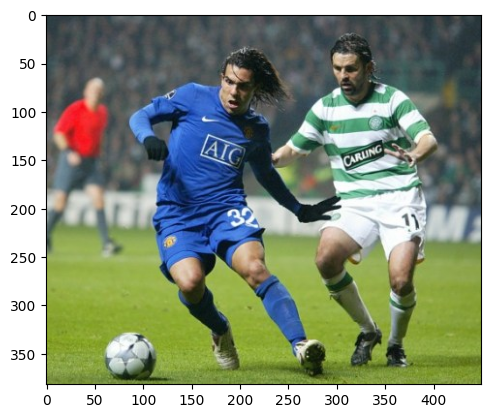

In [22]:
carlitosss = cv2.imread("../Imagenes_cursado/futbol.jpg")
img_rgb = cv2.cvtColor(carlitosss, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()


# Analisis RGB

Tenemos que definir una región dentro del hipercubo para el rango de colores de la region. Nos sería de interes extraer el uniforme del poderoso manchester united

24.7344 49.9068 186.2372


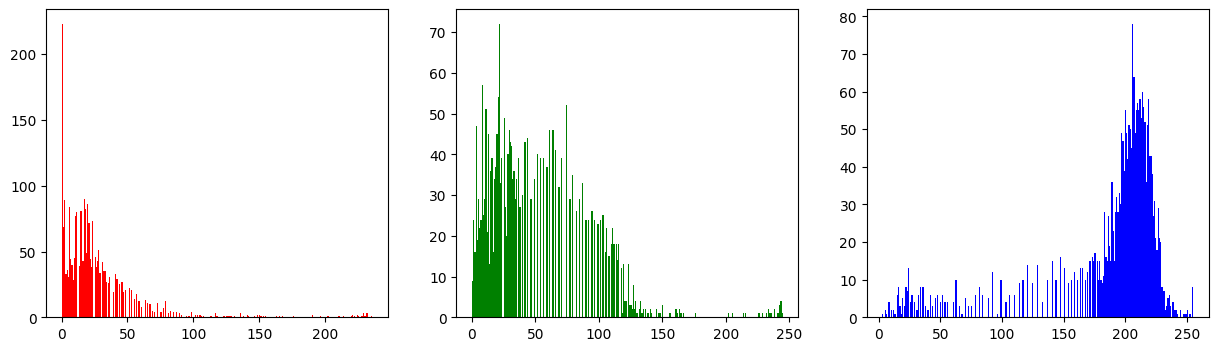

In [ ]:
r, g, b= cv2.split(img_rgb)
#aproximadamente voy a seleccionar una region de la camiseta y analizar la distribucion de los colores en esa region [150:150, 150:150]

r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

#tambien podria pasar un filtro pasabajo


fig, axs = plt.subplots(1, 3, figsize=(15,4))
axs[0].hist(np.ravel(r_eq[150:200, 150:200]), bins = 255, color = 'red')
axs[1].hist(np.ravel(g_eq[150:200, 150:200]), bins = 255, color = 'green')
axs[2].hist(np.ravel(b_eq[150:200, 150:200]), bins = 255, color = 'blue')

#el centro de mi esfera va a ser el centro de estos puntos

c_r = np.mean(np.ravel(r_eq[150:200, 150:200]))
c_g = np.mean(np.ravel(g_eq[150:200, 150:200]))
c_b= np.mean(np.ravel(b_eq[150:200, 150:200]))

r_std = np.std(np.ravel(r_eq[150:200, 150:200]))
g_std = np.std(np.ravel(g_eq[150:200, 150:200]))
b_std= np.std(np.ravel(b_eq[150:200, 150:200]))

desvio_prom = (r_std + g_std +b_std)/3 #porque el desvio del azul es muy grande!
print(c_r, c_g, c_b)
#para el radio vamos a elegir la desviación promedio de todas las dimension


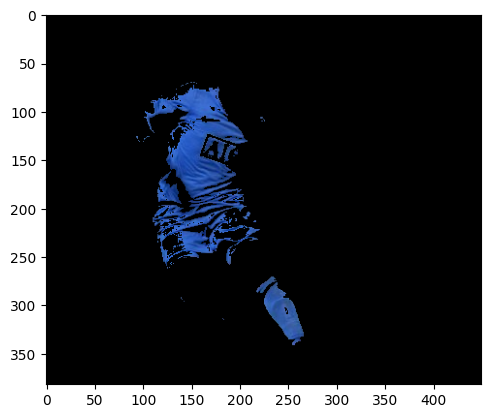

In [24]:
def sphere (point):
    if ((point[0]-c_r)**2 + (point[1]-c_g)**2 + (point[2]-c_b)**2)<(2*desvio_prom)**2:
        return True
    return False

#recorremos todas las matrices

roi_r = np.zeros_like(r)
roi_g = np.zeros_like(r)
roi_b = np.zeros_like(r)

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        point = np.array([
            r[i,j],
            g[i,j],
            b[i,j]]
        )
        if sphere(point) == True:
            roi_r[i,j] = r[i,j]
            roi_g[i,j] = g[i,j]
            roi_b[i,j] = b[i,j]

roi_rgb = cv2.merge([roi_r, roi_g, roi_b])
plt.imshow(roi_rgb)
plt.show()




# HSV

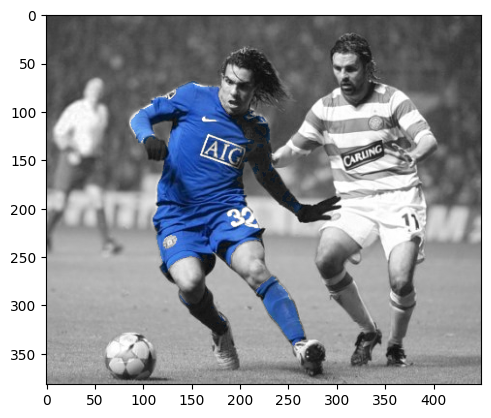

In [25]:
h, s, v = cv2.split(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV))
#necesito el intervalo de H azul nomas

#v_eq = cv2.equalizeHist(v) no suma nada si filtor por h y s

h_mean  = np.mean(np.ravel(h[150:200, 150:200]))
s_mean = np.mean(np.ravel(s[150:200, 150:200]))

h_std  = np.std(np.ravel(h[150:200, 150:200]))
s_std  = np.std(np.ravel(s[150:200, 150:200]))


k = 2

roi_h = np.zeros_like(h)
roi_s = np.zeros_like(s)


def hiperplane(point):
    if h_mean - k*h_std<point[0]<h_mean + k*h_std and s_mean - k*s_std< point[1]<s_mean + k*s_std:
        return True
    return False

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        point = np.array([
            h[i,j],
            s[i,j]]
        )
        if hiperplane(point) == True:
            roi_h[i,j] = h[i,j]
            roi_s[i,j] = s[i,j]


roi = cv2.merge([roi_h, roi_s, v])
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_HSV2RGB)

plt.imshow(roi_rgb)
plt.show()

#dou queda en gris








# ANALISIS DE PROFESORES!

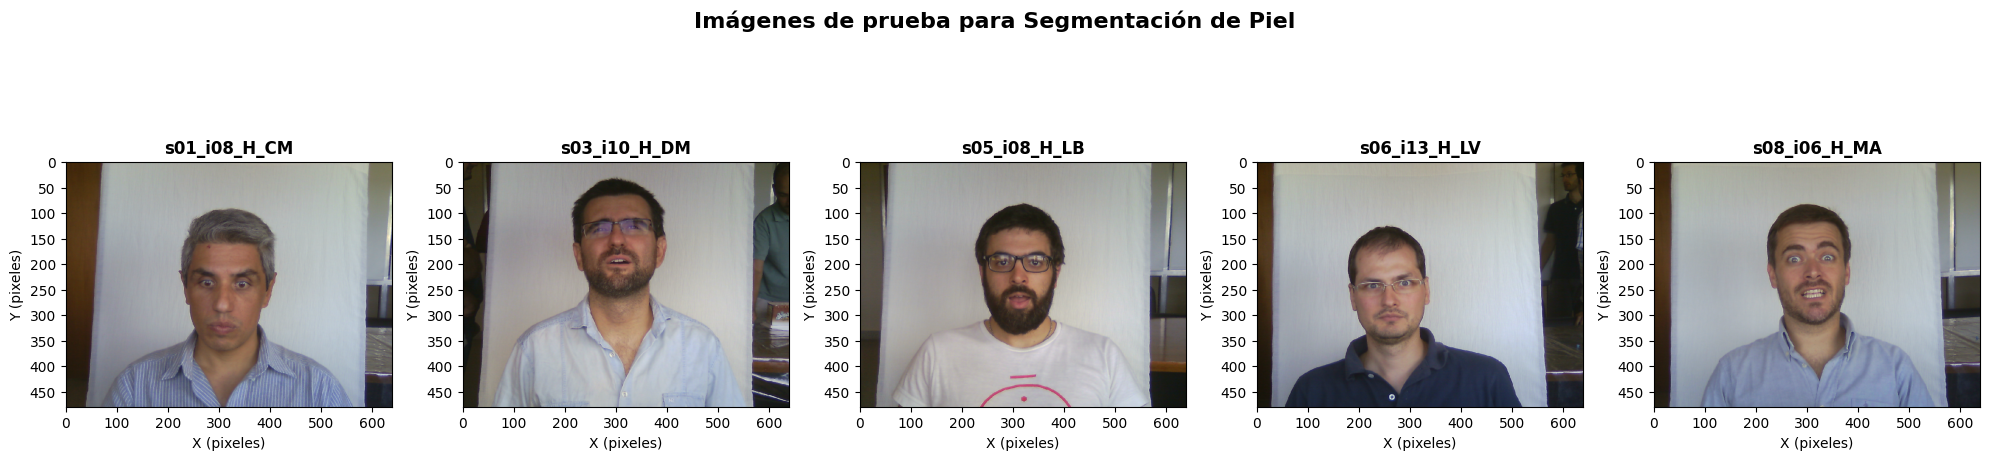

In [29]:
import cv2
import matplotlib.pyplot as plt
import os

nombres_imagenes = [
    "s01_i08_H_CM.png",
    "s03_i10_H_DM.png",
    "s05_i08_H_LB.png",
    "s06_i13_H_LV.png",
    "s08_i06_H_MA.png"
]
imgs_bgr = []
carpeta_base = "../Imagenes_cursado/"
fig, axes = plt.subplots(1, 5, figsize=(20, 5))


for i, nombre in enumerate(nombres_imagenes):
    ruta_completa = os.path.join(carpeta_base,nombre)
    img_bgr = cv2.imread(ruta_completa)

    if img_bgr is None:

        axes[i].text(0.5,0.5,f"No encontrada:\n{nombre}",ha='center',va='center',color='red',fontsize=10)
        axes[i].axis('off')
        print(f"Error: No se pudo cargar {ruta_completa}")
        continue

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    titulo = nombre.replace(".png", "")
    axes[i].imshow(img_rgb)
    axes[i].set_title(titulo,fontsize=12,fontweight='bold')

    axes[i].set_xlabel("X (pixeles)")
    axes[i].set_ylabel("Y (pixeles)")

    axes[i].set_xticks(range(0, img_rgb.shape[1], 100))
    axes[i].set_yticks(range(0, img_rgb.shape[0], 50))

    imgs_bgr.append(img_bgr)

plt.tight_layout()

plt.suptitle(
    "Imágenes de prueba para Segmentación de Piel",
    fontsize=16,
    y=1.05,
    fontweight='bold'
)

plt.show()

## Analisis rgb
Voy a extraer una muestra de la primera imagen a ojo y luego aplicare tales valores de rgb a todas las imagenes.
Preprocesamiento hare:
- Ecualizacion:
- Filtro pasa bajos

Todo para homogeneizar las zonas y pueda identificar mejor la piel.

# RGB
- Analizo la ROI
- Preproceso la imagen y aplico la roi a todas las imagenes.

Shape imagen: (480, 640, 3)
Alto: 480, Ancho: 640
Shape ROI: (40, 40, 3)
  Estadísticas de la ROI (RGB)

Canal R:
  mean    : 159.17
  std     : 9.31
  min     : 113.00
  max     : 176.00
  median  : 160.00

Canal G:
  mean    : 108.45
  std     : 8.93
  min     : 62.00
  max     : 132.00
  median  : 109.00

Canal B:
  mean    : 89.37
  std     : 7.36
  min     : 62.00
  max     : 108.00
  median  : 90.00


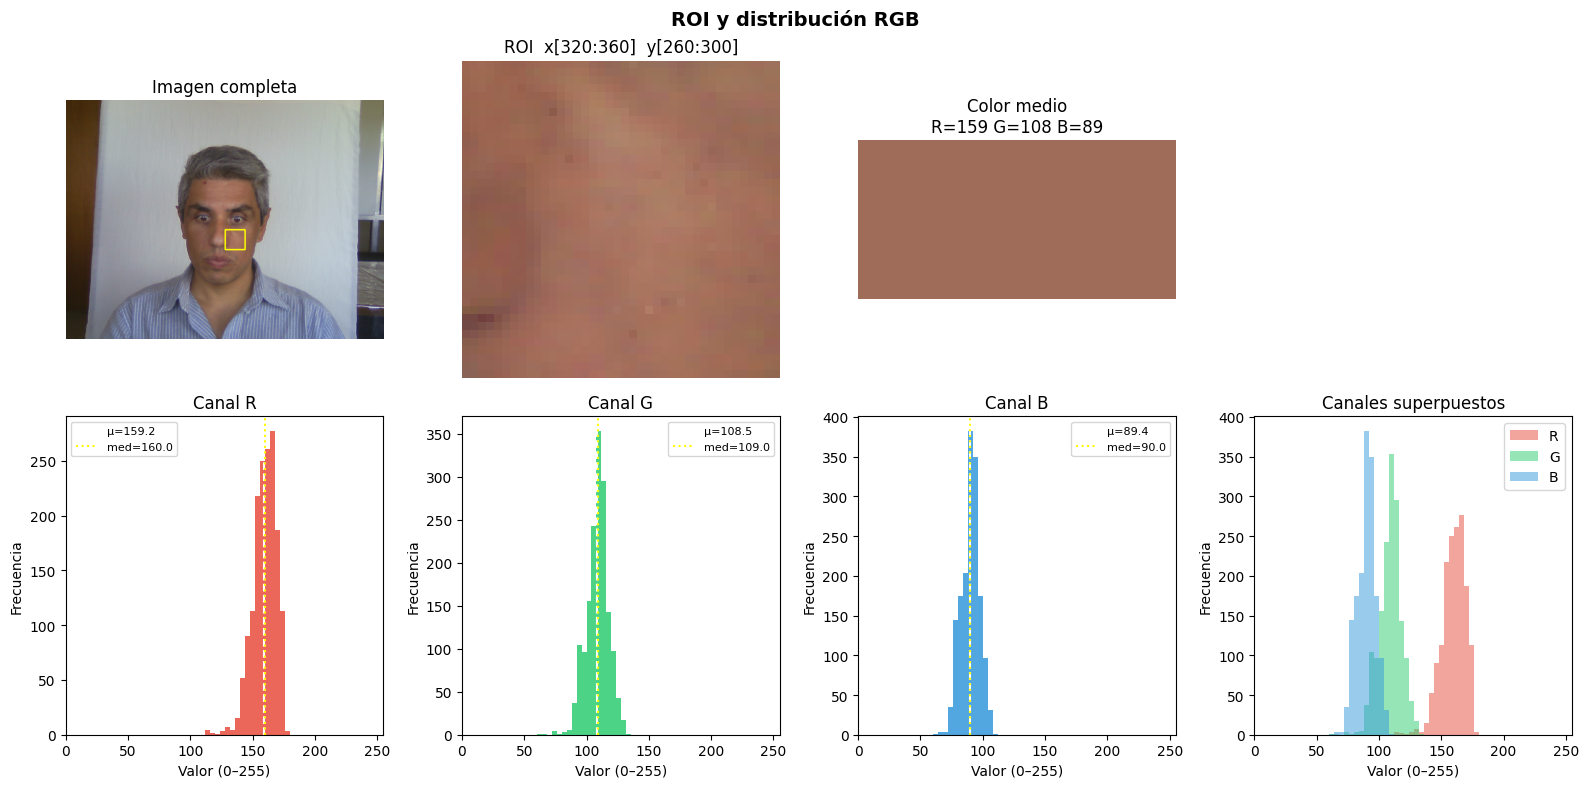

In [33]:
img_bgr = imgs_bgr[0] 

print(f"Shape imagen: {img_bgr.shape}")  
print(f"Alto: {img_bgr.shape[0]}, Ancho: {img_bgr.shape[1]}")

x1, x2 = 320, 360
y1, y2 = 260, 300

roi_bgr = img_bgr[y1:y2, x1:x2]
print(f"Shape ROI: {roi_bgr.shape}")   

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

R, G, B = cv2.split(roi_rgb)         
R, G, B = R.flatten(), G.flatten(), B.flatten()

stats = {}
for name, ch in zip(["R", "G", "B"], [R, G, B]):
    stats[name] = {
        "mean":   ch.mean(),
        "std":    ch.std(),
        "min":    ch.min(),
        "max":    ch.max(),
        "median": np.median(ch),
    }

print("=" * 45)
print("  Estadísticas de la ROI (RGB)")
print("=" * 45)
for ch, s in stats.items():
    print(f"\nCanal {ch}:")
    for k, v in s.items():
        print(f"  {k:8s}: {v:.2f}")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("ROI y distribución RGB", fontsize=14, fontweight="bold")

# ── Fila 0: imágenes ─────────────────────────────────────────────────────────
# Imagen completa con ROI marcada
ax_img = axes[0, 0]
img_show = img_rgb.copy()
cv2.rectangle(img_show, (x1, y1), (x2, y2), (255, 255, 0), 2)
ax_img.imshow(img_show)
ax_img.set_title("Imagen completa")
ax_img.axis("off")

# ROI ampliada
ax_roi = axes[0, 1]
ax_roi.imshow(roi_rgb)
ax_roi.set_title(f"ROI  x[{x1}:{x2}]  y[{y1}:{y2}]")
ax_roi.axis("off")

# Parche color medio
mean_color = np.array([R.mean(), G.mean(), B.mean()], dtype=np.uint8)
patch = np.full((50, 100, 3), mean_color, dtype=np.uint8)
ax_patch = axes[0, 2]
ax_patch.imshow(patch)
ax_patch.set_title(f"Color medio\nR={mean_color[0]} G={mean_color[1]} B={mean_color[2]}")
ax_patch.axis("off")

axes[0, 3].axis("off")  # celda vacía

colors   = {"R": "#e74c3c", "G": "#2ecc71", "B": "#3498db"}
channels = {"R": R,         "G": G,         "B": B}
bins     = np.arange(0, 257, 4)

for i, (ch_name, ch_data) in enumerate(channels.items()):
    ax = axes[1, i]
    ax.hist(ch_data, bins=bins, color=colors[ch_name], alpha=0.85, edgecolor="none")
    ax.axvline(ch_data.mean(),    color="white",  linestyle="--", lw=1.5, label=f"μ={ch_data.mean():.1f}")
    ax.axvline(np.median(ch_data), color="yellow", linestyle=":",  lw=1.5, label=f"med={np.median(ch_data):.1f}")
    ax.set_title(f"Canal {ch_name}")
    ax.set_xlabel("Valor (0–255)")
    ax.set_ylabel("Frecuencia")
    ax.set_xlim(0, 255)
    ax.legend(fontsize=8)

ax_all = axes[1, 3]
for ch_name, ch_data in channels.items():
    ax_all.hist(ch_data, bins=bins, color=colors[ch_name], alpha=0.5, edgecolor="none", label=ch_name)
ax_all.set_title("Canales superpuestos")
ax_all.set_xlabel("Valor (0–255)")
ax_all.set_ylabel("Frecuencia")
ax_all.set_xlim(0, 255)
ax_all.legend()

plt.tight_layout()
plt.show()

La idea seria aplicar a todas las imagenes:
- ecualizacion (no funciono bien)
- filtro de mediana

esto para homogeneizar la imagenes y la piel

luego buscar con la roi

In [38]:
import ipywidgets as widgets
from IPython.display import display

#preprocesamienot

def equalizar_rgb(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    r, g, b = cv2.split(img_rgb)
    r_eq = cv2.equalizeHist(r)
    g_eq = cv2.equalizeHist(g)
    b_eq = cv2.equalizeHist(b)
    #return cv2.merge([r_eq, g_eq, b_eq]) #la omito porque no funciono bien
    return cv2.merge([r,g,b])

def suavizar(img_rgb, ksize=5):
    # aplicamos mediana, homogeniza mucho
    #return cv2.medianBlur(img_rgb, ksize)
    return img_rgb

def preprocesar(img_bgr, ksize=5):
    img_eq   = equalizar_rgb(img_bgr)
    img_suav = suavizar(img_eq, ksize)
    return img_suav

def sphere_mask(img_rgb, center, radius):
    diff  = img_rgb.astype(np.float32) - center
    dist2 = np.sum(diff ** 2, axis=2)
    mask  = dist2 < radius ** 2
    return mask

def aplicar_mascara(img_rgb, mask):
    resultado = img_rgb.copy()
    resultado[~mask] = 0
    return resultado



center   = np.array([stats["R"]["mean"], stats["G"]["mean"], stats["B"]["mean"]])
std_prom = np.mean([stats["R"]["std"], stats["G"]["std"], stats["B"]["std"]])
imgs_proc = [preprocesar(img) for img in imgs_bgr]

# ploteo
def plotear_segmentacion(k):
    radius = k * std_prom
    n      = len(imgs_proc)

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    fig.suptitle(f"Segmentación esfera RGB  |  k={k:.1f}  radio={radius:.1f}", fontsize=13)

    for i, img in enumerate(imgs_proc):
        mask = sphere_mask(img, center, radius)
        seg  = aplicar_mascara(img, mask)

        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Imagen {i+1}")
        axes[0, i].axis("off")

        axes[1, i].imshow(seg)
        axes[1, i].set_title("Segmentada")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

#slider

slider = widgets.FloatSlider(
    value=2.0, min=0.5, max=6.0, step=0.1,
    description="k (radio):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

widgets.interact(plotear_segmentacion, k=slider)

interactive(children=(FloatSlider(value=2.0, description='k (radio):', layout=Layout(width='500px'), max=6.0, …

<function __main__.plotear_segmentacion(k)>

## HSV
Haremos lo mismo pero con HSV

In [ ]:
#Roi HSV
img_hsv  = cv2.cvtColor(imgs_bgr[0], cv2.COLOR_BGR2HSV)
roi_hsv  = img_hsv[y1:y2, x1:x2]

H_roi, S_roi, _ = cv2.split(roi_hsv) #no me importa el brillo
H_roi = H_roi.flatten()
S_roi = S_roi.flatten()

h_mean, h_std = H_roi.mean(), H_roi.std()
s_mean, s_std = S_roi.mean(), S_roi.std()

print(f"H:  media={h_mean:.1f}  std={h_std:.1f}")
print(f"S:  media={s_mean:.1f}  std={s_std:.1f}")

# Segmentacion por hiperplano
def hyperplane_mask(img_hsv, h_mean, h_std, s_mean, s_std, k):
    H, S, _ = cv2.split(img_hsv)
    H = H.astype(np.float32)
    S = S.astype(np.float32)

    en_H = (H > h_mean - k * h_std) & (H < h_mean + k * h_std)
    en_S = (S > s_mean - k * s_std) & (S < s_mean + k * s_std)

    return en_H & en_S

def aplicar_mascara(img_rgb, mask):
    resultado = img_rgb.copy()
    resultado[~mask] = 0
    return resultado



imgs_proc_hsv = [preprocesar(img) for img in imgs_bgr]   # reutilizamos preprocesar()



def plotear_hsv(k):
    n   = len(imgs_proc_hsv)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    fig.suptitle(f"Segmentación HS  |  k={k:.1f}", fontsize=13)

    for i, img_rgb in enumerate(imgs_proc_hsv):
        img_hsv_i = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        mask      = hyperplane_mask(img_hsv_i, h_mean, h_std, s_mean, s_std, k)
        seg       = aplicar_mascara(img_rgb, mask)

        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Imagen {i+1}")
        axes[0, i].axis("off")

        axes[1, i].imshow(seg)
        axes[1, i].set_title("Segmentada")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

# ── Slider ────────────────────────────────────────────────────────────────────

slider_hsv = widgets.FloatSlider(
    value=2.0, min=0.5, max=6.0, step=0.1,
    description="k (rango):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

widgets.interact(plotear_hsv, k=slider_hsv)

H:  media=8.2  std=1.4
S:  media=112.0  std=5.9


interactive(children=(FloatSlider(value=2.0, description='k (rango):', layout=Layout(width='500px'), max=6.0, …

<function __main__.plotear_hsv(k)>

Mucho mejores resultados